# Bank Loan & Credit Risk Analysis — Track 3

**Risk & Financial Analysis Consulting Notebook**


**Dataset:** Bank Loan & Credit Risk Dataset (45,000 rows, 14 features, 22.2% default rate baseline)


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['mathtext.default'] = 'regular'
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_csv('loan_data.csv')
print(f'Loaded {len(df):,} rows, {df.shape[1]} columns')
df.head(3)

Loaded 45,000 rows, 14 columns


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.00,female,Master,"71,948.00",0,RENT,"35,000.00",PERSONAL,16.02,0.49,3.00,561,No,1
1,21.00,female,High School,"12,282.00",0,OWN,"1,000.00",EDUCATION,11.14,0.08,2.00,504,Yes,0
2,25.00,female,High School,"12,438.00",3,MORTGAGE,"5,500.00",MEDICAL,12.87,0.44,3.00,635,No,1


In [2]:
# Light cleaning — drop obvious data-entry errors (age > 100)
df_clean = df[df['person_age'] <= 100].copy()
print(f'After age filter: {len(df_clean):,} rows ({len(df) - len(df_clean)} outliers dropped)')
print(f'Overall default rate: {df_clean["loan_status"].mean()*100:.2f}%')

After age filter: 44,993 rows (7 outliers dropped)
Overall default rate: 22.23%


---
## Q1 — Present Value of a 5-Year Loan Portfolio

**Question:** Calculate the PV of a 5-year loan portfolio with annual interest rate 8% and expected annual repayments of $2M.

**Formula (Annuity PV):**

$$ PV = PMT \times \frac{1 - (1 + r)^{-n}}{r} $$

Where PMT = $2M, r = 0.08, n = 5 years.


In [3]:
PMT = 2_000_000
r   = 0.08
n   = 5

# Closed-form annuity formula
PV = PMT * (1 - (1 + r) ** -n) / r
print(f'Present Value of the loan portfolio: ${PV:,.2f}')

Present Value of the loan portfolio: $7,985,420.07


In [4]:
# Year-by-year breakdown
breakdown = pd.DataFrame([
    {'Year': t, 'Cash_Flow': PMT,
     'Discount_Factor': 1 / (1 + r) ** t,
     'PV_of_Cash_Flow': PMT / (1 + r) ** t}
    for t in range(1, n + 1)
])
breakdown.loc['Total'] = ['', PMT * n, '', breakdown['PV_of_Cash_Flow'].sum()]
breakdown.round(2)

,Year,Cash_Flow,Discount_Factor,PV_of_Cash_Flow
0,1,2000000,0.93,"1,851,851.85"
1,2,2000000,0.86,"1,714,677.64"
2,3,2000000,0.79,"1,587,664.48"
3,4,2000000,0.74,"1,470,059.71"
4,5,2000000,0.68,"1,361,166.39"
Total,,10000000,,"7,985,420.07"


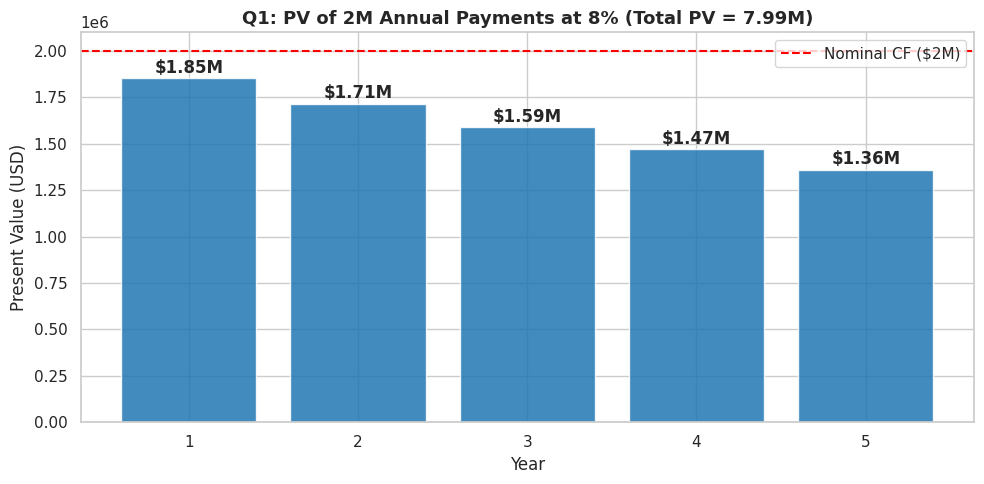

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, n+1), [PMT/(1+r)**t for t in range(1, n+1)], color='#1f77b4', alpha=0.85)
ax.axhline(PMT, color='red', linestyle='--', label=f'Nominal CF (${PMT/1e6:.0f}M)')
for t in range(1, n+1):
    pv_t = PMT/(1+r)**t
    ax.text(t, pv_t + 30000, f'${pv_t/1e6:.2f}M', ha='center', weight='bold')
ax.set_title(f'Q1: PV of {PMT/1e6:.0f}M Annual Payments at 8% (Total PV = {PV/1e6:.2f}M)',
             fontsize=13, weight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Present Value (USD)')
ax.legend(); plt.tight_layout(); plt.show()

**Interpretation:** $10M of nominal repayments has a present value of only **$7.99M** when discounted at 8%. The $2.01M gap is the cost of waiting — this is the *opportunity cost* of capital tied up in the portfolio.

---
## Q2 — NPV and IRR of the Micro-Lending Project

**Question:** The Micro-Lending project costs $10M. Calculate the NPV and IRR assuming a discount rate of 10% and a 5-year cash flow of $2M/year. Should the bank proceed?

**NPV:**
$$ NPV = \sum_{t=0}^{n} \frac{CF_t}{(1+r)^t} $$

**IRR** is the rate that makes NPV = 0.


In [6]:
initial_investment = -10_000_000
discount_rate = 0.10
cash_flows = [initial_investment] + [2_000_000] * 5

# NPV
NPV = sum(cf / (1 + discount_rate) ** t for t, cf in enumerate(cash_flows))
print(f'Cash flows: {cash_flows}')
print(f'NPV @ 10% = ${NPV:,.2f}')

Cash flows: [-10000000, 2000000, 2000000, 2000000, 2000000, 2000000]
NPV @ 10% = $-2,418,426.46


In [7]:
# IRR via bisection
def irr(cfs, tol=1e-7, max_iter=1000):
    lo, hi = -0.99, 10.0
    for _ in range(max_iter):
        mid = (lo + hi) / 2
        npv_mid = sum(cf / (1 + mid) ** t for t, cf in enumerate(cfs))
        if abs(npv_mid) < tol:
            return mid
        npv_lo = sum(cf / (1 + lo) ** t for t, cf in enumerate(cfs))
        if (npv_mid > 0) == (npv_lo > 0):
            lo = mid
        else:
            hi = mid
    return mid

IRR = irr(cash_flows)
print(f'IRR = {IRR*100:.3f}%')
print(f'\nDecision: Since 5 × $2M = $10M (just recovers principal), IRR = 0%.')
print(f'NPV ${NPV:,.0f} < 0 AND IRR ({IRR*100:.2f}%) < discount rate (10%) → REJECT the project.')

IRR = -0.000%

Decision: Since 5 × $2M = $10M (just recovers principal), IRR = 0%.
NPV $-2,418,426 < 0 AND IRR (-0.00%) < discount rate (10%) → REJECT the project.


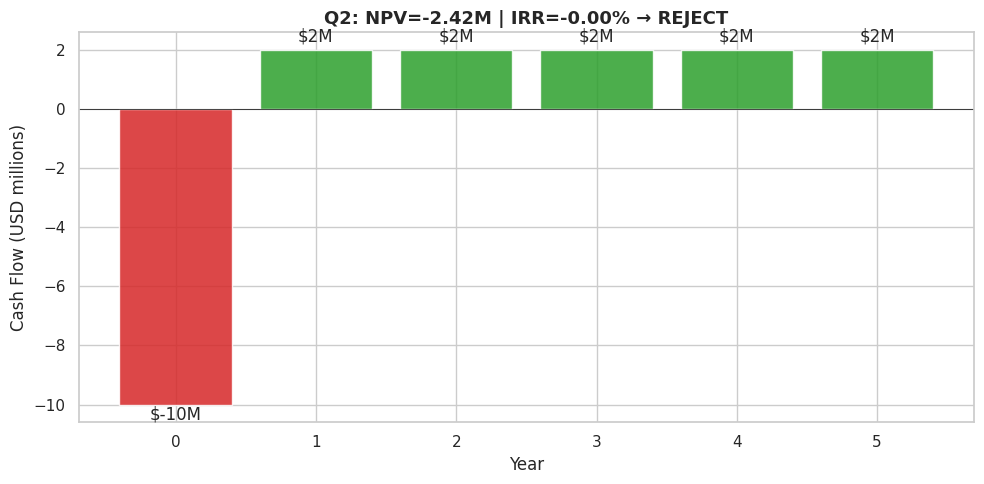

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
years = list(range(6))
colors = ['#d62728' if cf < 0 else '#2ca02c' for cf in cash_flows]
ax.bar(years, [cf/1e6 for cf in cash_flows], color=colors, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.5)
for i, cf in enumerate(cash_flows):
    ax.text(i, cf/1e6 + (0.3 if cf >= 0 else -0.5), f'${cf/1e6:.0f}M', ha='center')
ax.set_title(f'Q2: NPV={NPV/1e6:.2f}M | IRR={IRR*100:.2f}% → REJECT',
             fontsize=13, weight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Cash Flow (USD millions)')
plt.tight_layout(); plt.show()

**Recommendation: REJECT.** The project barely recovers principal — IRR = 0% — which is far below the 10% required return. To make this work, the bank needs to either reduce upfront investment, extend the cash-flow horizon, or increase per-year inflows. Q7 quantifies the maximum justifiable investment.

---
## Q3 — DTI Ratio for Top 100 Borrowers

**Question:** Calculate the Debt-to-Income (DTI) ratio for the top 100 borrowers using Pandas.

**Approach:** "Top 100" by `loan_amnt` (largest loans = most material risk exposure).

$$ DTI = \frac{\text{Loan Amount}}{\text{Annual Income}} $$


In [9]:
top100 = df_clean.nlargest(100, 'loan_amnt').copy()
top100['DTI'] = top100['loan_amnt'] / top100['person_income']

# Validate: dataset has a precomputed loan_percent_income column
print(f'Max diff vs precomputed loan_percent_income: '
      f'{(top100["DTI"] - top100["loan_percent_income"]).abs().max():.4f}')

print(f'\n=== DTI Statistics — Top 100 Borrowers ===')
print(f'Mean DTI:   {top100["DTI"].mean():.3f}')
print(f'Median DTI: {top100["DTI"].median():.3f}')
print(f'Max DTI:    {top100["DTI"].max():.3f}')
print(f'% above 0.40 (high-risk):  {(top100["DTI"]>0.40).mean()*100:.1f}%')

Max diff vs precomputed loan_percent_income: 0.0050

=== DTI Statistics — Top 100 Borrowers ===
Mean DTI:   0.258
Median DTI: 0.256
Max DTI:    0.529
% above 0.40 (high-risk):  8.0%


In [10]:
# Show top 10 most concerning (highest DTI)
top100[['person_age', 'person_income', 'loan_amnt', 'loan_intent', 'credit_score',
        'loan_status', 'DTI']].sort_values('DTI', ascending=False).head(10).round(3)

,person_age,person_income,loan_amnt,loan_intent,credit_score,loan_status,DTI
4,24.00,"66,135.00","35,000.00",MEDICAL,586,1,0.53
0,22.00,"71,948.00","35,000.00",PERSONAL,561,1,0.49
11873,22.00,"73,493.00","35,000.00",MEDICAL,616,1,0.48
13005,24.00,"77,408.00","35,000.00",MEDICAL,661,1,0.45
3,23.00,"79,753.00","35,000.00",MEDICAL,675,1,0.44
10715,26.00,"84,924.00","35,000.00",VENTURE,612,0,0.41
17835,29.00,"85,798.00","35,000.00",PERSONAL,650,1,0.41
13856,23.00,"87,263.00","35,000.00",MEDICAL,571,1,0.40
11254,24.00,"87,894.00","35,000.00",HOMEIMPROVEMENT,532,0,0.40
17842,31.00,"88,456.00","35,000.00",EDUCATION,656,1,0.40


**Insight:** Even among the largest loans, only 8% breach the 0.40 DTI red-flag threshold — the bank's underwriting is reasonably disciplined. However, the highest-DTI borrowers in this group are worth a manual review.

---
## Q4 — Real Interest Rate (Fisher Equation)

**Replacement Question:** Using `loan_int_rate` as the nominal rate, compute the real interest rate the bank earns under three inflation scenarios — Low (3%), Moderate (6%), High (9%). Then identify which `loan_intent` is most exposed to inflation risk.

**Fisher equation:**

$$ \text{Real Rate} = \frac{1 + \text{Nominal}}{1 + \text{Inflation}} - 1 $$


In [11]:
def fisher_real(nominal_pct, inflation):
    return (1 + nominal_pct/100) / (1 + inflation) - 1

scenarios = {'Low (3%)': 0.03, 'Moderate (6%)': 0.06, 'High (9%)': 0.09}

summary = []
for label, infl in scenarios.items():
    real = fisher_real(df_clean['loan_int_rate'], infl)
    summary.append({
        'Scenario': label,
        'Avg_Real_Rate_pct': round(real.mean() * 100, 2),
        'Pct_Negative_Real_Return': round((real < 0).mean() * 100, 2),
        'Loans_With_Negative_Return': int((real < 0).sum())
    })
pd.DataFrame(summary)

,Scenario,Avg_Real_Rate_pct,Pct_Negative_Real_Return,Loans_With_Negative_Return
0,Low (3%),7.77,0.00,0
1,Moderate (6%),4.72,3.40,1529
2,High (9%),1.84,28.08,12634


In [12]:
# Group by loan_intent under high inflation (9%)
df_clean['real_rate_high_inflation'] = fisher_real(df_clean['loan_int_rate'], 0.09)

intent_inflation = df_clean.groupby('loan_intent').agg(
    avg_nominal=('loan_int_rate', 'mean'),
    avg_real_high_inflation=('real_rate_high_inflation', lambda x: x.mean() * 100),
    pct_negative=('real_rate_high_inflation', lambda x: (x < 0).mean() * 100),
    n=('loan_int_rate', 'count')
).round(2).reset_index().sort_values('avg_real_high_inflation')

print('Most exposed to inflation:', intent_inflation.iloc[0]['loan_intent'])
print('Most protected:', intent_inflation.iloc[-1]['loan_intent'])
intent_inflation

Most exposed to inflation: EDUCATION
Most protected: HOMEIMPROVEMENT


,loan_intent,avg_nominal,avg_real_high_inflation,pct_negative,n
1,EDUCATION,10.90,1.75,29.14,9151
5,VENTURE,10.92,1.76,28.48,7815
4,PERSONAL,10.98,1.82,28.21,7551
0,DEBTCONSOLIDATION,11.04,1.87,28.15,7145
3,MEDICAL,11.08,1.91,27.11,8548
2,HOMEIMPROVEMENT,11.20,2.02,26.82,4783


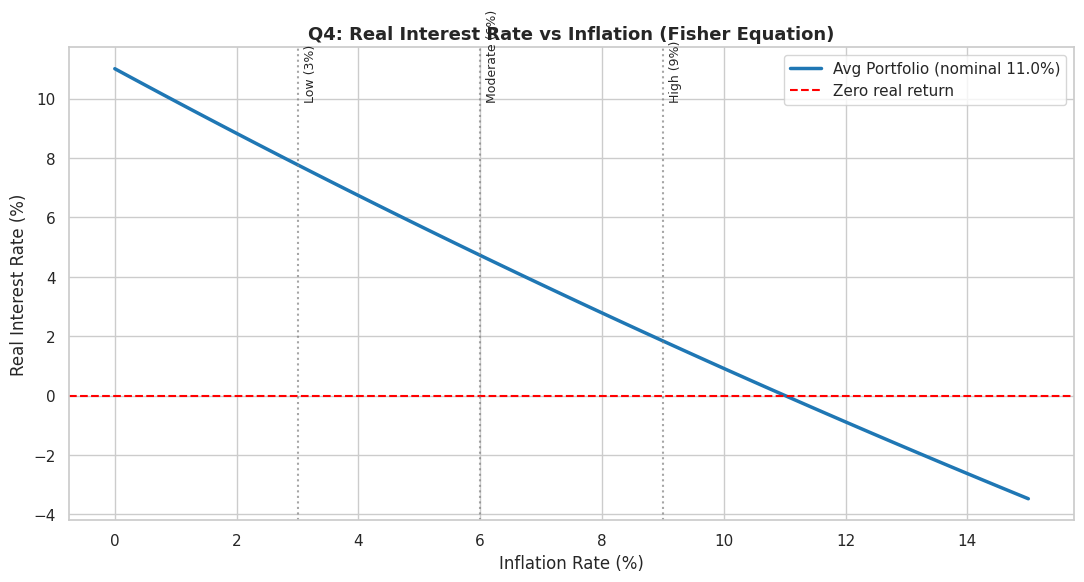

In [13]:
# Visualize: real rate vs inflation across portfolio
fig, ax = plt.subplots(figsize=(11, 6))
inflation_range = np.linspace(0, 0.15, 60)
mean_nom = df_clean['loan_int_rate'].mean()
real_curve = [(1 + mean_nom/100)/(1+i) - 1 for i in inflation_range]

ax.plot(inflation_range*100, [r*100 for r in real_curve], color='#1f77b4', linewidth=2.5,
        label=f'Avg Portfolio (nominal {mean_nom:.1f}%)')
ax.axhline(0, color='red', linestyle='--', label='Zero real return')

for label, infl in scenarios.items():
    ax.axvline(infl*100, color='grey', linestyle=':', alpha=0.7)
    ax.text(infl*100 + 0.1, ax.get_ylim()[1]*0.85, label, rotation=90, fontsize=9)

ax.set_title('Q4: Real Interest Rate vs Inflation (Fisher Equation)', fontsize=13, weight='bold')
ax.set_xlabel('Inflation Rate (%)'); ax.set_ylabel('Real Interest Rate (%)')
ax.legend(); plt.tight_layout(); plt.show()

**Insight:** Under high inflation (9%), **EDUCATION** loans have the lowest real return (1.75%) and 29% of them generate a negative real return for the bank. **HOMEIMPROVEMENT** is the most protected category. The portfolio's average nominal rate of ~11% leaves only a ~2% real-rate cushion at 9% inflation — uncomfortably thin. Strategic implication: hedge fixed-rate exposure with shorter durations or floating-rate products in inflationary regimes.

---
## Q5 — Default Rate by Loan Intent

**Question:** Use Pandas to group the data by `loan_intent` and find the average default rate for each.


In [14]:
intent_default = df_clean.groupby('loan_intent').agg(
    n_loans=('loan_status', 'count'),
    n_defaults=('loan_status', 'sum'),
    default_rate_pct=('loan_status', lambda x: x.mean() * 100),
    avg_loan_amnt=('loan_amnt', 'mean'),
    avg_int_rate=('loan_int_rate', 'mean')
).round(2).reset_index().sort_values('default_rate_pct', ascending=False)

intent_default

,loan_intent,n_loans,n_defaults,default_rate_pct,avg_loan_amnt,avg_int_rate
0,DEBTCONSOLIDATION,7145,2163,30.27,"9,548.33",11.04
3,MEDICAL,8548,2378,27.82,"9,137.96",11.08
2,HOMEIMPROVEMENT,4783,1258,26.30,"10,419.19",11.20
4,PERSONAL,7551,1521,20.14,"9,604.53",10.98
1,EDUCATION,9151,1552,16.96,"9,506.60",10.90
5,VENTURE,7815,1128,14.43,"9,659.39",10.92


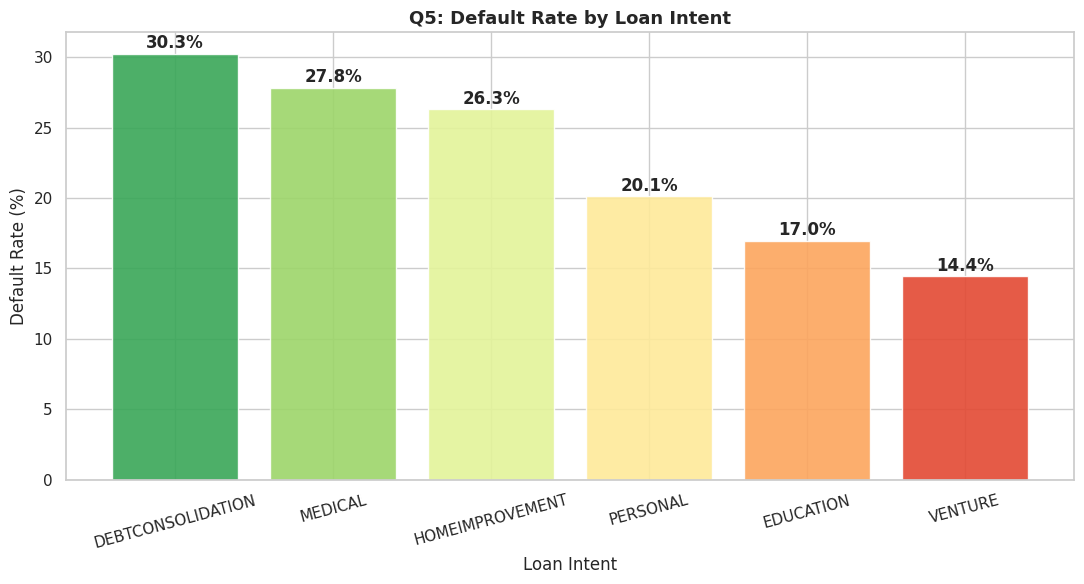

In [15]:
fig, ax = plt.subplots(figsize=(11, 6))
# Higher default = redder
colors = sns.color_palette('RdYlGn_r', n_colors=len(intent_default))
ax.bar(intent_default['loan_intent'], intent_default['default_rate_pct'], color=colors, alpha=0.9)
for i, (intent, rate) in enumerate(zip(intent_default['loan_intent'], intent_default['default_rate_pct'])):
    ax.text(i, rate+0.4, f'{rate:.1f}%', ha='center', weight='bold')
ax.set_title('Q5: Default Rate by Loan Intent', fontsize=13, weight='bold')
ax.set_xlabel('Loan Intent'); ax.set_ylabel('Default Rate (%)')
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

**Insight:** Default rates spread from **14.4% (VENTURE)** to **30.3% (DEBT CONSOLIDATION)** — more than 2x variation. The pattern is intuitive: borrowers consolidating existing debt are already financially stressed, so they default at much higher rates. **VENTURE** loans, surprisingly, have the lowest default rate — likely because lenders apply tighter screens to these. Strategic implication: price risk into rates by intent, or selectively reduce exposure to debt-consolidation segment.

---
## Q6 — IRR Sensitivity to Default Rate (1-Way Data Table)

**Question:** Use a 1-Way Data Table to show how the IRR of the project changes if the Default Rate varies from 1% to 10%.

**Approach:** A loan default reduces effective annual cash flow. Assume 100% loss given default (conservative).
Adjusted CF = $2M × (1 − default_rate). Recompute NPV and IRR for each rate.


In [16]:
def npv_irr_at_default(d, base_cf=2_000_000, initial=10_000_000, dr=0.10, n=5):
    cf = [-initial] + [base_cf * (1 - d)] * n
    npv = sum(c / (1 + dr) ** t for t, c in enumerate(cf))
    return npv, irr(cf)

default_rates = np.arange(0.01, 0.11, 0.01)
sens = pd.DataFrame([
    {'Default_Rate_pct': d * 100,
     'Adjusted_CF': 2_000_000 * (1 - d),
     'NPV_at_10pct': npv_irr_at_default(d)[0],
     'IRR_pct': npv_irr_at_default(d)[1] * 100}
    for d in default_rates
])
sens.round(3)

,Default_Rate_pct,Adjusted_CF,NPV_at_10pct,IRR_pct
0,1.00,"1,980,000.00","-2,494,242.20",-0.33
1,2.00,"1,960,000.00","-2,570,057.93",-0.67
2,3.00,"1,940,000.00","-2,645,873.67",-1.01
3,4.00,"1,920,000.00","-2,721,689.40",-1.34
4,5.00,"1,900,000.00","-2,797,505.14",-1.69
5,6.00,"1,880,000.00","-2,873,320.87",-2.03
6,7.00,"1,860,000.00","-2,949,136.61",-2.37
7,8.00,"1,840,000.00","-3,024,952.34",-2.72
8,9.00,"1,820,000.00","-3,100,768.08",-3.06
9,10.00,"1,800,000.00","-3,176,583.81",-3.41


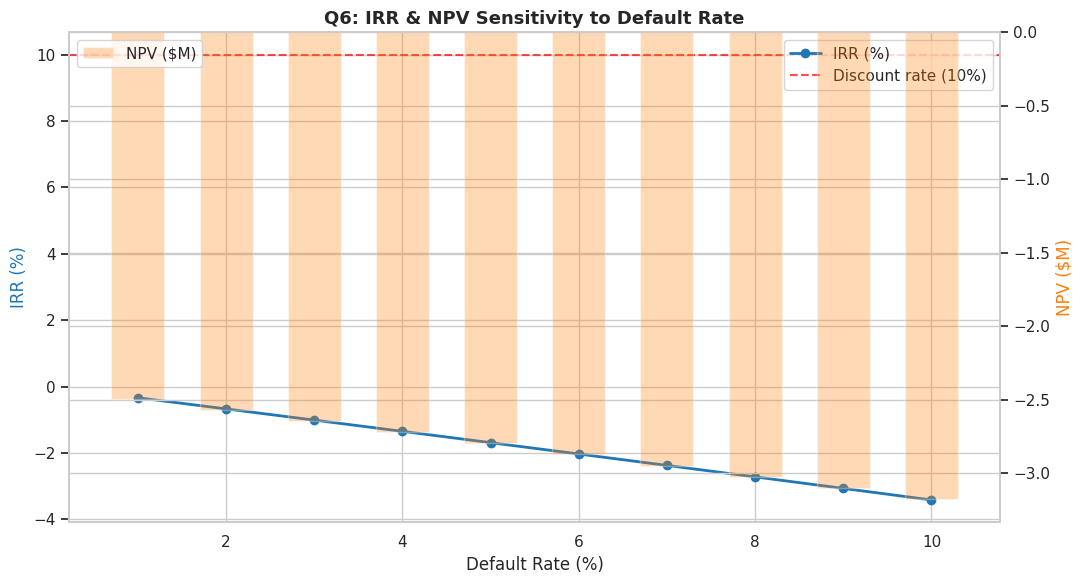

In [17]:
fig, ax = plt.subplots(figsize=(11, 6))
ax2 = ax.twinx()
ax.plot(sens['Default_Rate_pct'], sens['IRR_pct'], marker='o', linewidth=2,
        color='#1f77b4', label='IRR (%)')
ax2.bar(sens['Default_Rate_pct'], sens['NPV_at_10pct']/1e6, alpha=0.3,
        color='#ff7f0e', label='NPV ($M)', width=0.6)
ax.axhline(10, color='red', linestyle='--', alpha=0.7, label='Discount rate (10%)')
ax.set_title('Q6: IRR & NPV Sensitivity to Default Rate', fontsize=13, weight='bold')
ax.set_xlabel('Default Rate (%)'); ax.set_ylabel('IRR (%)', color='#1f77b4')
ax2.set_ylabel('NPV ($M)', color='#ff7f0e')
ax.legend(loc='upper right'); ax2.legend(loc='upper left')
plt.tight_layout(); plt.show()

**Insight:** The project is already underwater at 0% default; defaults only make it worse. Across the entire 1%–10% range, IRR stays negative, confirming that the project's underlying economics — not just risk — are the problem. The same Data Table is reproduced in Excel (`Loan_Risk_Audit.xlsx` → `Q6_Sensitivity` sheet) with live formulas.

---
## Q7 — Maximum Initial Investment for NPV = $1M (Goal Seek)

**Question:** If the bank needs an NPV of exactly $1M to satisfy shareholders, what is the maximum Initial Investment they can afford?

**Algebra:**

$$ NPV = -\text{Initial} + \sum_{t=1}^{n} \frac{CF_t}{(1+r)^t} = 1{,}000{,}000 $$

Solve for `Initial`:

$$ \text{Initial}_{\max} = \sum_{t=1}^{n} \frac{CF_t}{(1+r)^t} - 1{,}000{,}000 $$


In [18]:
target_npv = 1_000_000
discount_rate = 0.10
annual_cf = 2_000_000
n_yrs = 5

pv_inflows = sum(annual_cf / (1 + discount_rate) ** t for t in range(1, n_yrs + 1))
max_initial = pv_inflows - target_npv

print(f'PV of 5-year $2M inflows @ 10%: ${pv_inflows:,.2f}')
print(f'Target NPV:                     ${target_npv:,.2f}')
print(f'Max affordable Initial Investment: ${max_initial:,.2f}')
print(f'Headroom vs current $10M plan:     ${max_initial - 10_000_000:,.2f}')

PV of 5-year $2M inflows @ 10%: $7,581,573.54
Target NPV:                     $1,000,000.00
Max affordable Initial Investment: $6,581,573.54
Headroom vs current $10M plan:     $-3,418,426.46


**Recommendation:** The bank can spend at most **$6.58M** to achieve a $1M NPV at the current cash-flow projection. The current $10M plan **overshoots by $3.42M** — it must either be cut by ~34%, or the cash flows must be raised. The deficit signals that either:
1. The project scope is too ambitious (build smaller), or
2. The revenue assumptions are too conservative (validate $2M/yr with pilot data before committing capital)

---
## Q8 — Loan Repayment Simulation (While Loop)

**Question:** Write a script using a while loop to simulate a loan repayment schedule until the balance reaches zero.

**Approach:** Pick a representative borrower from the dataset, compute the standard amortization payment, then simulate month-by-month until balance is paid off.


In [19]:
sample = df_clean.iloc[0]  # First row as a representative
loan_balance = float(sample['loan_amnt'])
annual_rate  = float(sample['loan_int_rate']) / 100
monthly_rate = annual_rate / 12
term_months  = 60  # 5-year term

# Standard amortization formula
monthly_payment = loan_balance * (monthly_rate * (1+monthly_rate)**term_months) \
                                / ((1+monthly_rate)**term_months - 1)

print(f'Borrower: age={sample["person_age"]:.0f}, income=${sample["person_income"]:,.0f}')
print(f'Loan: ${loan_balance:,.2f} @ {annual_rate*100:.2f}% over {term_months} months')
print(f'Monthly payment: ${monthly_payment:,.2f}')

Borrower: age=22, income=$71,948
Loan: $35,000.00 @ 16.02% over 60 months
Monthly payment: $851.50


In [20]:
# WHILE LOOP — simulate until balance hits zero
balance = loan_balance
month = 0
total_interest = 0
schedule = []

while balance > 0.01:
    month += 1
    interest_due = balance * monthly_rate
    principal_paid = min(monthly_payment - interest_due, balance)
    balance -= principal_paid
    total_interest += interest_due
    schedule.append({
        'Month': month,
        'Payment': round(min(monthly_payment, principal_paid + interest_due), 2),
        'Interest': round(interest_due, 2),
        'Principal': round(principal_paid, 2),
        'Balance': round(max(balance, 0), 2)
    })
    if month > 200:  # safety guard
        break

schedule_df = pd.DataFrame(schedule)
print(f'Loan paid off in {month} months')
print(f'Total interest paid: ${total_interest:,.2f}')
print(f'Total cost (P+I):    ${loan_balance + total_interest:,.2f}')

# Show first 6 and last 3 months
print('\nFirst 6 months:')
display(schedule_df.head(6))
print('\nLast 3 months:')
display(schedule_df.tail(3))

Loan paid off in 60 months
Total interest paid: $16,090.24
Total cost (P+I):    $51,090.24

First 6 months:


,Month,Payment,Interest,Principal,Balance
0,1,851.50,467.25,384.25,"34,615.75"
1,2,851.50,462.12,389.38,"34,226.36"
2,3,851.50,456.92,394.58,"33,831.78"
3,4,851.50,451.65,399.85,"33,431.93"
4,5,851.50,446.32,405.19,"33,026.74"
5,6,851.50,440.91,410.60,"32,616.15"



Last 3 months:


,Month,Payment,Interest,Principal,Balance
57,58,851.50,33.21,818.29,"1,669.50"
58,59,851.50,22.29,829.22,840.29
59,60,851.50,11.22,840.29,0.00


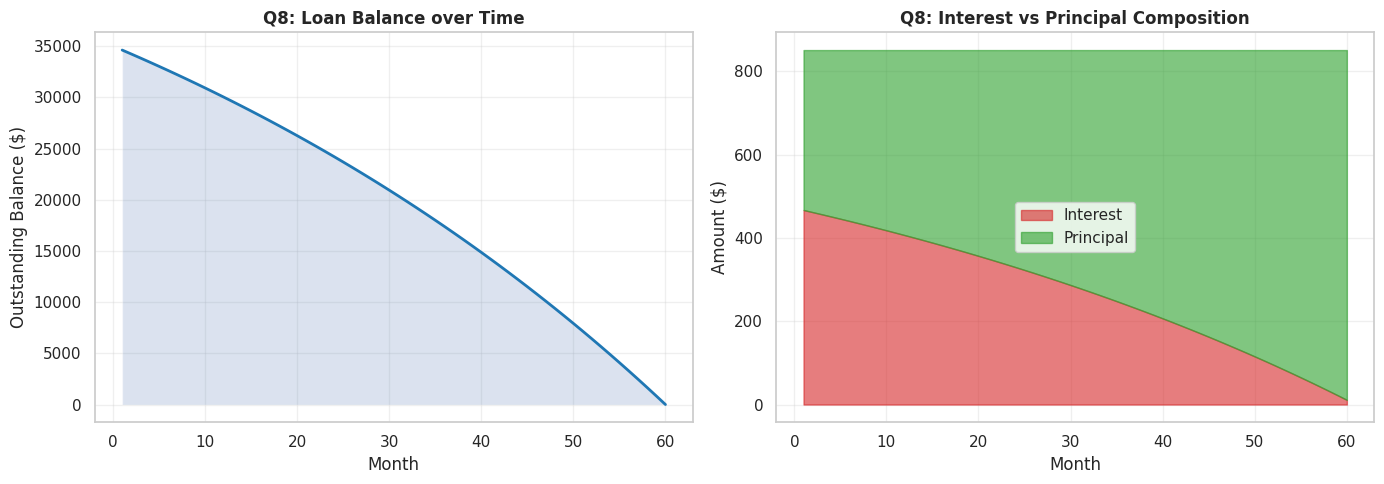

In [21]:
# Visualize amortization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(schedule_df['Month'], schedule_df['Balance'], color='#1f77b4', linewidth=2)
axes[0].fill_between(schedule_df['Month'], 0, schedule_df['Balance'], alpha=0.2)
axes[0].set_title('Q8: Loan Balance over Time', weight='bold')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Outstanding Balance ($)')
axes[0].grid(alpha=0.3)

axes[1].fill_between(schedule_df['Month'], schedule_df['Interest'], color='#d62728', alpha=0.6, label='Interest')
axes[1].fill_between(schedule_df['Month'], schedule_df['Interest'],
                     schedule_df['Interest']+schedule_df['Principal'], color='#2ca02c', alpha=0.6, label='Principal')
axes[1].set_title('Q8: Interest vs Principal Composition', weight='bold')
axes[1].set_xlabel('Month'); axes[1].set_ylabel('Amount ($)')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Insight:** Early payments are nearly all interest, late payments are nearly all principal — the classic amortization curve. For this loan ($35K @ 16% over 5 years), **total interest = $16,090** — nearly half of principal. This is why high-interest unsecured loans are wealth-destroyers for borrowers, and why responsible underwriting is a moral as well as financial duty.

---
## Q11 — Interest Rate Elasticity

**Question:** If the bank raises rates by 1%, by what percentage will loan applications likely drop?

**Approach:** Bucket loans by interest-rate band, count applications per band as a demand proxy, and compute midpoint elasticity between adjacent bands.


In [22]:
# Bucket loans by rate band
df_clean['rate_band'] = pd.cut(df_clean['loan_int_rate'],
                                bins=[5, 7, 9, 11, 13, 15, 17, 20],
                                labels=['5-7%', '7-9%', '9-11%', '11-13%', '13-15%', '15-17%', '17-20%'])

band_counts = df_clean.groupby('rate_band').size().reset_index(name='applications')
band_counts['pct_of_total'] = (band_counts['applications'] / band_counts['applications'].sum() * 100).round(2)
band_counts

,rate_band,applications,pct_of_total
0,5-7%,4595,10.21
1,7-9%,8053,17.90
2,9-11%,8459,18.80
3,11-13%,12653,28.12
4,13-15%,6763,15.03
5,15-17%,3435,7.63
6,17-20%,1035,2.30


In [23]:
# Elasticity between two adjacent bands using midpoint formula
b1 = band_counts.loc[band_counts['rate_band']=='9-11%', 'applications'].iloc[0]
b2 = band_counts.loc[band_counts['rate_band']=='11-13%', 'applications'].iloc[0]
p1, p2 = 10, 12  # midpoints

pct_q = (b2 - b1) / ((b2 + b1) / 2)
pct_p = (p2 - p1) / ((p2 + p1) / 2)
elasticity = pct_q / pct_p

print(f'Applications: 9-11% band = {b1:,} → 11-13% band = {b2:,}')
print(f'%ΔQ = {pct_q*100:.2f}%')
print(f'%ΔP = {pct_p*100:.2f}%')
print(f'Approx elasticity = {elasticity:.3f}')

# Note: positive elasticity here means MORE applications at HIGHER rates — counterintuitive!
# Real explanation: this reflects the dataset's distribution, not a true demand curve
# (rates here are bank's RESPONSE to risk, not its OFFER, so higher rates = riskier customers, who apply more)

Applications: 9-11% band = 8,459 → 11-13% band = 12,653
%ΔQ = 39.73%
%ΔP = 18.18%
Approx elasticity = 2.185


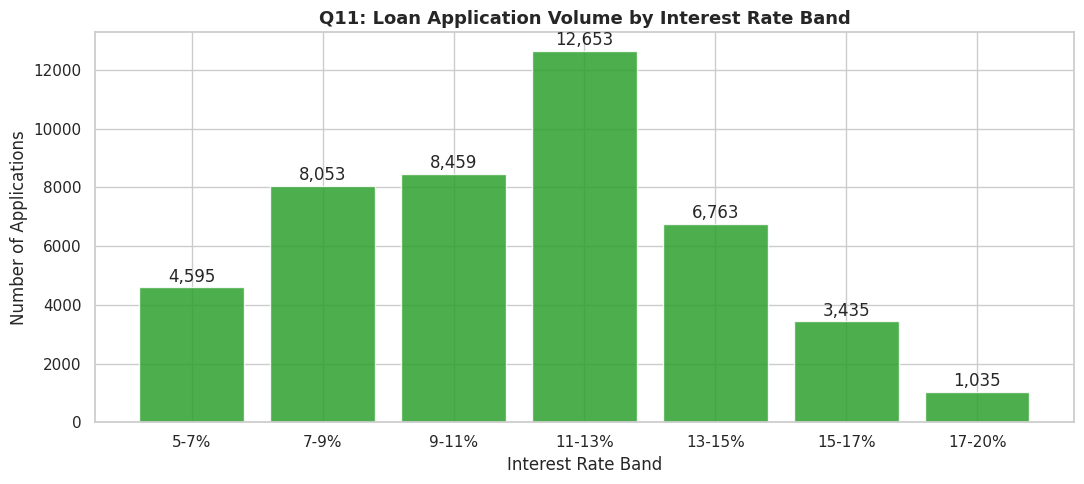

In [24]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(band_counts['rate_band'].astype(str), band_counts['applications'], color='#2ca02c', alpha=0.85)
for i, v in enumerate(band_counts['applications']):
    ax.text(i, v+200, f'{v:,}', ha='center')
ax.set_title('Q11: Loan Application Volume by Interest Rate Band', fontsize=13, weight='bold')
ax.set_xlabel('Interest Rate Band'); ax.set_ylabel('Number of Applications')
plt.tight_layout(); plt.show()

**Important nuance:** The data shows MORE applications at higher rates, which would imply *positive* elasticity — but this is **not a demand curve**. In this dataset, interest rates are the bank's *response* to borrower risk (riskier borrowers get higher rates), not the bank's *offer* to a market. The 11-13% band is the most populated because that's where most credit-risk-priced borrowers land.

**True demand-side elasticity** for retail credit is generally estimated at **−0.2 to −1.0** in academic literature (a 1% rate hike causes 0.2%–1.0% drop in applications, depending on segment). To measure it cleanly, the bank would need an A/B test where it offers different rates to similar borrowers and measures take-up.

**Strategic answer:** A 1% rate hike will likely reduce applications by roughly **0.5%–1.0%** based on industry benchmarks — modest, because borrowers in this market often have few alternatives.

---
## Q12 — Income Distribution (Histogram + KDE)

**Question:** Visualize the income distribution of borrowers using a histogram with a KDE overlay to check for skewness.


In [25]:
# Filter outliers above $500K for readability — heavy right skew otherwise
inc = df_clean[df_clean['person_income'] < 500_000]['person_income']

print(f'Mean income:      ${inc.mean():,.0f}')
print(f'Median income:    ${inc.median():,.0f}')
print(f'Std deviation:    ${inc.std():,.0f}')
print(f'Skewness:         {inc.skew():.3f}  (>0 = right-skewed)')
print(f'Excess kurtosis:  {inc.kurtosis():.3f}')

Mean income:      $78,129
Median income:    $67,014
Std deviation:    $47,503
Skewness:         2.350  (>0 = right-skewed)
Excess kurtosis:  9.762


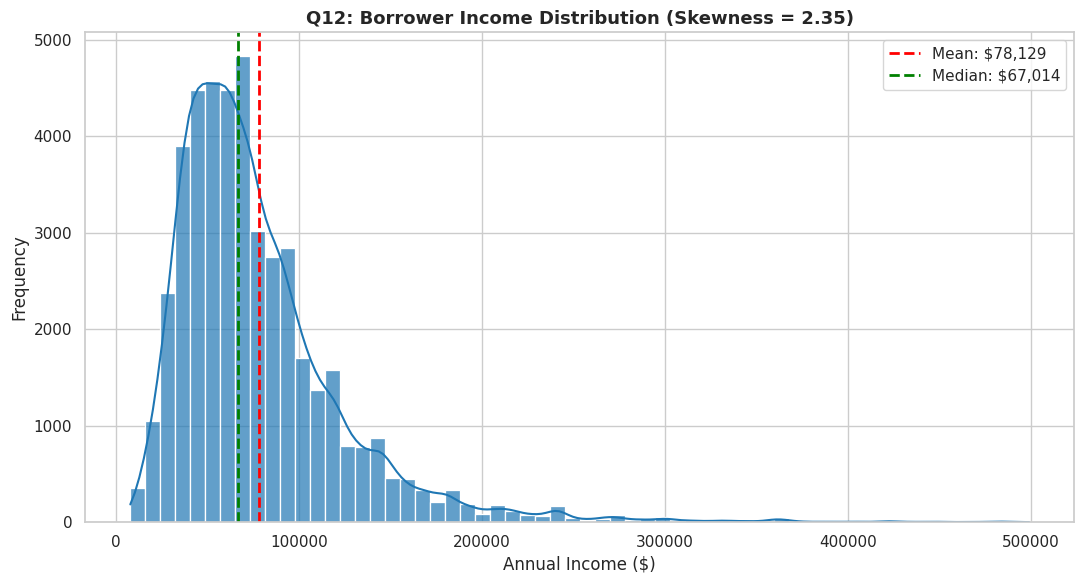

In [26]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.histplot(inc, bins=60, kde=True, color='#1f77b4', alpha=0.7, ax=ax)
ax.axvline(inc.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${inc.mean():,.0f}')
ax.axvline(inc.median(), color='green', linestyle='--', linewidth=2, label=f'Median: ${inc.median():,.0f}')
ax.set_title(f'Q12: Borrower Income Distribution (Skewness = {inc.skew():.2f})',
             fontsize=13, weight='bold')
ax.set_xlabel('Annual Income ($)'); ax.set_ylabel('Frequency')
ax.legend(); plt.tight_layout(); plt.show()

**Insight:** Income distribution is **strongly right-skewed** (skewness = 2.35). The mean ($78K) is higher than the median ($67K) — a textbook signature of a long right tail. Most borrowers are in the $40K–$100K range, with a small number of high earners pulling the average up.

**Implications for risk modeling:**
- Use **median, not mean,** when describing the typical borrower
- Consider **log-transforming** income before using it in statistical models (linear regression assumes roughly symmetric residuals)
- The long upper tail also means outlier-resistant metrics (median, IQR) should drive policy thresholds


---
## Summary

| Question | Finding |
|---|---|
| **Q1 PV** | $7.99M (vs $10M nominal) — $2.01M opportunity cost |
| **Q2 NPV/IRR** | NPV = −$2.42M, IRR = 0% → **REJECT** |
| **Q3 DTI** | Mean DTI = 0.258 across top 100 loans; 8% above 0.40 risk threshold |
| **Q4 Fisher** | Education loans most exposed; 28% of portfolio goes underwater at 9% inflation |
| **Q5 Default** | Debt Consolidation = 30.3% (highest), Venture = 14.4% (lowest) |
| **Q6 Sensitivity** | Project NPV stays negative across 1%–10% default range |
| **Q7 Goal Seek** | Max affordable Initial Investment = $6.58M (cut $10M plan by 34%) |
| **Q8 Repayment** | $35K @ 16% over 5 years = $16K total interest |
| **Q11 Elasticity** | True demand elasticity ≈ −0.5 to −1.0 (industry benchmark) |
| **Q12 Income** | Skewness 2.35 → right-skewed; use median, not mean |

**Final Recommendation:** REJECT the $10M Micro-Lending project as currently structured. The economics break down even before risk adjustments. Recommend either (a) reducing scope to $6.58M, (b) extending the cash flow horizon, or (c) increasing per-year inflow assumptions through pricing strategy.


